# Data-scaling / learning-curve analysis

Picks one finished sweep run's **architecture + loss hyperparameters** (via
`RUN_ID`) and the exact train/val split it used, then **retrains that recipe
from scratch** on shrinking fractions of the train set to see whether
`val/goal_metric` is still climbing (more data would help) or has flattened
(the model/architecture is the bottleneck, not data quantity).

- Fractions tested: 0.1%, 0.3%, 1%, 3%, 10%, 30%, 100% of the *subsample-eligible*
  pool (see below), each repeated over `N_BOOTSTRAP` random draws (without
  replacement) except 100%, which is the single deterministic full train set.
- **Always-include pool:** every train molecule with continuous **pProp >= 5.0**
  is included in *every* draw, at every fraction -- these are scarce, high-value
  molecules we don't want an unlucky small-fraction draw to lose entirely. Only
  the pProp < 5.0 pool (the bulk of the data) is actually subsampled.
- Epochs are fixed at the source run's own `config["epochs"]` for every
  fraction/iteration, so training recipe is held constant and train-set size is
  the only thing that varies.
- Metric tracked: `goal_metric = AP* + 0.5*(Pearson* + MAE_skill*)` where
  `AP* = 0.5*(macro_ap_obj + weighted_ap_obj)`, `Pearson* = 0.5*(pearson +
  pearson_weighted)`, `MAE_skill* = 0.5*(mae_skill + weighted_mae_skill)` --
  the exact objective `sweeps/sweep.yaml` maximizes and that `src/sweep_train.py`
  stores in each run's `final_meta.json` (see `_goal_metric` below). Computed on
  both the train subsample actually used and the full, fixed val set.
- No wandb logging -- this notebook runs everything locally and keeps results
  in an in-memory `pandas.DataFrame`.

Complementary to `sweeps/analyze_sweep.ipynb` (cross-run hyperparameter
importance at fixed data) and `sweeps/eval_best_model.ipynb` (single-model
deep dive at fixed data) -- this notebook is the one that varies **data
quantity** instead.

In [1]:
import sys
import json
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F

REPO_ROOT = Path.cwd().parent if Path.cwd().name == "sweeps" else Path.cwd()
sys.path.insert(0, str(REPO_ROOT / "src"))
RUNS_DIR = REPO_ROOT / "runs"

from model import DualHeadMLP
from data_utils import build_split_arrays, load_ecfp_features, CACHE_DIR
from normalization import compute_norm_stats, normalize_pprop
from losses import (
    inverse_frequency_weights,
    sample_weights_from_classes,
    weighted_huber_loss,
    pairwise_distance_loss,
    std_match_loss,
)
from sweep_train import evaluate

## Pick the source run + scaling params

`RUN_ID` supplies the architecture, loss hyperparameters, and `split_dir` to
reuse -- copy one from `analyze_sweep.ipynb`'s top-N table or any completed
run under `runs/`.

In [2]:
RUN_ID = "x2e3fofl"  # <-- edit me

FRACTIONS = [0.001, 0.003, 0.01, 0.03, 0.1, 0.3, 1.0]
N_BOOTSTRAP = 10          # bootstrap iterations per fraction (100% always uses 1)
ALWAYS_INCLUDE_PPROP = 5.0  # train molecules with pprop >= this are never subsampled
RNG_SEED = 0

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"device: {device}")

device: cuda:0


## Load the source run's config

Read straight from `runs/<RUN_ID>/final_meta.json` -- no checkpoint weights
needed, since every model here is trained fresh.

In [3]:
meta = json.loads((RUNS_DIR / RUN_ID / "final_meta.json").read_text())
cfg = meta["config"]
split_dir = REPO_ROOT / cfg["split_dir"]
use_ecfp = bool(cfg.get("use_ecfp", 0))

print(f"run_id: {RUN_ID}")
print(f"split_dir: {split_dir}")
print(f"source run val_goal_metric (full train set, trained weights): {meta['val_goal_metric']:.4f}")
print("config:")
print(json.dumps(cfg, indent=2))

run_id: x2e3fofl
split_dir: /home/ethan2/pProp_MLP/data/split_1
source run val_goal_metric (full train set, trained weights): 1.4413
config:
{
  "split_dir": "data/split_1",
  "seed": 0,
  "use_ecfp": 0,
  "pprop_norm": "zscore",
  "n_layers": 2,
  "hidden_dim": 1412,
  "cls_n_layers": 0,
  "cls_hidden_dim": 222,
  "reg_n_layers": 3,
  "reg_hidden_dim": 315,
  "w_cls": 0.17315337740292924,
  "w_pair": 0.08781500514218112,
  "w_std": 0.008099680814458655,
  "huber_delta": 1.497880825614717,
  "init_lr": 0.0004067457882283225,
  "weight_decay": 2.7313619297407848e-05,
  "dropout": 0.21917813938762964,
  "batch_size": 2774,
  "epochs": 72,
  "eta_min": 1e-08,
  "in_dim": 512,
  "n_classes": 4,
  "task": "dual",
  "class_weights": [
    0.1088,
    0.3177,
    3.4648,
    0.1088
  ],
  "weight_groups": [
    0,
    1,
    2,
    0
  ],
  "objective_classes": [
    "0-3.5",
    "3.5-5",
    "5-7.5"
  ],
  "norm_stats": {
    "strategy": "zscore",
    "mean": 2.392370151325869,
    "std": 1.

## Load the full train/val data for this run's split

This is the fixed pool every fraction/iteration draws its training subset
from; the val set is never subsampled.

In [4]:
embeddings = np.load(CACHE_DIR / "minimol_embeddings.npy")
smiles_index = (CACHE_DIR / "minimol_smiles.txt").read_text().splitlines()

extra_features = [load_ecfp_features()] if use_ecfp else None
data = build_split_arrays(split_dir, embeddings, smiles_index, return_pprop=True,
                           extra_features=extra_features)

class_names = data["class_names"]
X_train_full = torch.as_tensor(data["X_train"], dtype=torch.float32, device=device)
y_train_full = torch.as_tensor(data["y_train"], dtype=torch.long, device=device)
pprop_train_full = torch.as_tensor(data["pprop_train"], dtype=torch.float32, device=device)
X_val = torch.as_tensor(data["X_val"], dtype=torch.float32, device=device)
y_val = torch.as_tensor(data["y_val"], dtype=torch.long, device=device)
pprop_val = torch.as_tensor(data["pprop_val"], dtype=torch.float32, device=device)

always_mask = (pprop_train_full >= ALWAYS_INCLUDE_PPROP).cpu().numpy()
n_always = int(always_mask.sum())
n_variable = len(always_mask) - n_always
print(f"train set: {X_train_full.shape[0]} molecules total")
print(f"  always-include (pProp >= {ALWAYS_INCLUDE_PPROP}): {n_always}")
print(f"  subsample-eligible (pProp < {ALWAYS_INCLUDE_PPROP}): {n_variable}")
print(f"val set (fixed, never subsampled): {X_val.shape[0]} molecules")

train set: 530644 molecules total
  always-include (pProp >= 5.0): 12135
  subsample-eligible (pProp < 5.0): 518509
val set (fixed, never subsampled): 93191 molecules


## Subsampling helper

`fraction` is applied to the pProp < `ALWAYS_INCLUDE_PPROP` pool only; the
always-include pool is added on top of every draw. `fraction == 1.0` returns
the untouched full train set (deterministic, no RNG).

In [5]:
def draw_train_subset(X_train, y_train, pprop_train, always_mask, fraction, seed):
    """Always-include pool (pprop >= threshold) + a `fraction`-sized random draw
    (without replacement) from the pprop < threshold pool."""
    always_idx = np.where(always_mask)[0]
    variable_idx = np.where(~always_mask)[0]

    if fraction >= 1.0:
        keep_idx = np.arange(len(always_mask))
    else:
        rng = np.random.RandomState(seed)
        n_draw = round(fraction * len(variable_idx))
        drawn_idx = rng.choice(variable_idx, size=n_draw, replace=False)
        keep_idx = np.concatenate([always_idx, drawn_idx])

    keep_idx = torch.as_tensor(np.sort(keep_idx), dtype=torch.long, device=X_train.device)
    return X_train[keep_idx], y_train[keep_idx], pprop_train[keep_idx]

## Train-one-run function

Adapted from the training loop in `src/sweep_train.py` (`main()`), which has
no importable `train()` function of its own -- it's inlined and coupled to
`argparse`/`wandb`. This copies just the loop body (batching, loss, optimizer,
scheduler) and reuses `sweep_train.evaluate` for metrics rather than
reimplementing it.

In [6]:
def _goal_metric(m):
    """The sweep objective, computed exactly as src/sweep_train.py does
    (lines 252-257):

        goal_metric = AP* + 0.5 * (Pearson* + MAE_skill*)
          AP*        = 0.5 * (macro_ap_obj + weighted_ap_obj)
          Pearson*   = 0.5 * (pearson + pearson_weighted)
          MAE_skill* = 0.5 * (mae_skill + weighted_mae_skill)

    `evaluate()` already returns every key here (it passes
    objective_classes=OBJECTIVE_CLASSES / groups=WEIGHT_GROUPS internally), so
    this must match the stored `val_goal_metric` in final_meta.json -- do NOT
    reintroduce the old `3*macro_ap + pearson_weighted - weighted_mae` formula.
    """
    ap_star = 0.5 * (m["macro_ap_obj"] + m["weighted_ap_obj"])
    pearson_star = 0.5 * (m["pearson"] + m["pearson_weighted"])
    mae_skill_star = 0.5 * (m["mae_skill"] + m["weighted_mae_skill"])
    return ap_star + 0.5 * (pearson_star + mae_skill_star)


def train_one_run(cfg, X_tr, y_tr, pprop_tr, X_val, y_val, pprop_val,
                   class_names, device, seed):
    """Train a fresh DualHeadMLP with `cfg`'s hyperparameters on (X_tr, y_tr,
    pprop_tr), then return (train_goal_metric, val_goal_metric)."""
    torch.manual_seed(seed)

    norm_stats = compute_norm_stats(pprop_tr.cpu().numpy(), cfg["pprop_norm"])
    pprop_tr_norm = normalize_pprop(pprop_tr, norm_stats)

    class_weights = inverse_frequency_weights(y_tr.cpu().numpy(), len(class_names))
    class_weights_dev = class_weights.to(device)

    model = DualHeadMLP(
        in_dim=cfg["in_dim"], hidden_dim=cfg["hidden_dim"], n_layers=cfg["n_layers"],
        dropout=cfg["dropout"], cls_hidden_dim=cfg["cls_hidden_dim"], cls_n_layers=cfg["cls_n_layers"],
        reg_hidden_dim=cfg["reg_hidden_dim"], reg_n_layers=cfg["reg_n_layers"],
        n_classes=len(class_names),
    ).to(device)

    optimizer = torch.optim.AdamW(model.parameters(), lr=cfg["init_lr"], weight_decay=cfg["weight_decay"])
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=cfg["epochs"], eta_min=cfg["eta_min"])

    n_train = X_tr.shape[0]
    for epoch in range(cfg["epochs"]):
        model.train()
        perm = torch.randperm(n_train, device=device)
        for start in range(0, n_train, cfg["batch_size"]):
            idx = perm[start:start + cfg["batch_size"]]
            optimizer.zero_grad()
            cls_logits, reg_out = model(X_tr[idx])
            pred = reg_out.squeeze(-1)
            cls_loss = F.cross_entropy(cls_logits, y_tr[idx], weight=class_weights_dev)
            sample_w = sample_weights_from_classes(y_tr[idx], class_weights_dev)
            huber = weighted_huber_loss(reg_out, pprop_tr_norm[idx], sample_w, delta=cfg["huber_delta"])
            pair = pairwise_distance_loss(pred, pprop_tr_norm[idx])
            std_loss = std_match_loss(pred, pprop_tr_norm[idx])
            loss = cfg["w_cls"] * cls_loss + huber + cfg["w_pair"] * pair + cfg["w_std"] * std_loss
            loss.backward()
            optimizer.step()
        scheduler.step()

    train_m = evaluate(model, X_tr, y_tr, pprop_tr, class_weights, cfg["w_cls"],
                        cfg["w_pair"], cfg["w_std"], cfg["huber_delta"], class_names, device, norm_stats)
    val_m = evaluate(model, X_val, y_val, pprop_val, class_weights, cfg["w_cls"],
                      cfg["w_pair"], cfg["w_std"], cfg["huber_delta"], class_names, device, norm_stats)

    train_goal = _goal_metric(train_m)
    val_goal = _goal_metric(val_m)
    return train_goal, val_goal

## Run the fraction x bootstrap sweep

`N_BOOTSTRAP` iterations per fraction, except 100% (single deterministic run,
same molecules as the source run's own train set). Total runs:
`(len(FRACTIONS) - 1) * N_BOOTSTRAP + 1`.

In [7]:
records = []
total_runs = (len(FRACTIONS) - 1) * N_BOOTSTRAP + 1
run_i = 0

for frac in FRACTIONS:
    n_iters = 1 if frac >= 1.0 else N_BOOTSTRAP
    for it in range(n_iters):
        run_i += 1
        seed = RNG_SEED * 1000 + it
        t0 = time.time()

        X_tr, y_tr, pprop_tr = draw_train_subset(
            X_train_full, y_train_full, pprop_train_full, always_mask, frac, seed
        )
        train_goal, val_goal = train_one_run(
            cfg, X_tr, y_tr, pprop_tr, X_val, y_val, pprop_val, class_names, device, seed
        )

        elapsed = time.time() - t0
        records.append({
            "fraction": frac, "iter": it, "n_train": int(X_tr.shape[0]),
            "train_goal_metric": train_goal, "val_goal_metric": val_goal,
        })
        print(f"[{run_i}/{total_runs}] frac={frac:<7} iter={it} n_train={X_tr.shape[0]:>7} "
              f"train_goal={train_goal:.4f} val_goal={val_goal:.4f} ({elapsed:.1f}s)")

df = pd.DataFrame(records)
df

[1/61] frac=0.001   iter=0 n_train=  12654 train_goal=1.5348 val_goal=1.0987 (3.2s)
[2/61] frac=0.001   iter=1 n_train=  12654 train_goal=1.5493 val_goal=1.1107 (2.3s)
[3/61] frac=0.001   iter=2 n_train=  12654 train_goal=1.4116 val_goal=1.1178 (2.3s)
[4/61] frac=0.001   iter=3 n_train=  12654 train_goal=1.3894 val_goal=1.0798 (2.3s)
[5/61] frac=0.001   iter=4 n_train=  12654 train_goal=1.5226 val_goal=1.1091 (2.4s)
[6/61] frac=0.001   iter=5 n_train=  12654 train_goal=1.5224 val_goal=1.1102 (2.4s)
[7/61] frac=0.001   iter=6 n_train=  12654 train_goal=1.4874 val_goal=1.0874 (2.4s)
[8/61] frac=0.001   iter=7 n_train=  12654 train_goal=1.5154 val_goal=1.1053 (2.4s)
[9/61] frac=0.001   iter=8 n_train=  12654 train_goal=1.4999 val_goal=1.0959 (2.4s)
[10/61] frac=0.001   iter=9 n_train=  12654 train_goal=1.4665 val_goal=1.0978 (2.4s)
[11/61] frac=0.003   iter=0 n_train=  13691 train_goal=1.6075 val_goal=1.1930 (2.5s)
[12/61] frac=0.003   iter=1 n_train=  13691 train_goal=1.5994 val_goal=1.1

,fraction,iter,n_train,train_goal_metric,val_goal_metric
0,0.001,0,12654,1.534796,1.098654
1,0.001,1,12654,1.549309,1.110725
2,0.001,2,12654,1.411575,1.117823
3,0.001,3,12654,1.389352,1.079757
4,0.001,4,12654,1.522578,1.109056
...,...,...,...,...,...
56,0.300,6,167688,1.536099,1.261190
57,0.300,7,167688,1.507293,1.236800
58,0.300,8,167688,1.530736,1.261615
59,0.300,9,167688,1.530899,1.255234


## Aggregate + plot

Mean and min/max range per fraction across the bootstrap iterations. 100%
has a single iteration, so it renders as a lone point with no band.

In [8]:
agg = df.groupby("fraction").agg(
    n_train_mean=("n_train", "mean"),
    train_mean=("train_goal_metric", "mean"),
    train_min=("train_goal_metric", "min"),
    train_max=("train_goal_metric", "max"),
    val_mean=("val_goal_metric", "mean"),
    val_min=("val_goal_metric", "min"),
    val_max=("val_goal_metric", "max"),
).reset_index()
agg

,fraction,n_train_mean,train_mean,train_min,train_max,val_mean,val_min,val_max
0,0.001,12654.0,1.489922,1.389352,1.549309,1.101260,1.079757,1.117823
1,0.003,13691.0,1.576247,1.513696,1.623054,1.171250,1.152757,1.192961
2,0.010,17320.0,1.622749,1.583718,1.660287,1.232105,1.215195,1.242367
3,0.030,27690.0,1.607496,1.578604,1.646410,1.251965,1.227589,1.273427
4,0.100,63986.0,1.558185,1.525249,1.592170,1.237611,1.212154,1.273398
5,0.300,167688.0,1.530422,1.507293,1.561772,1.257935,1.236800,1.294654
6,1.000,530644.0,1.596876,1.596876,1.596876,1.377624,1.377624,1.377624


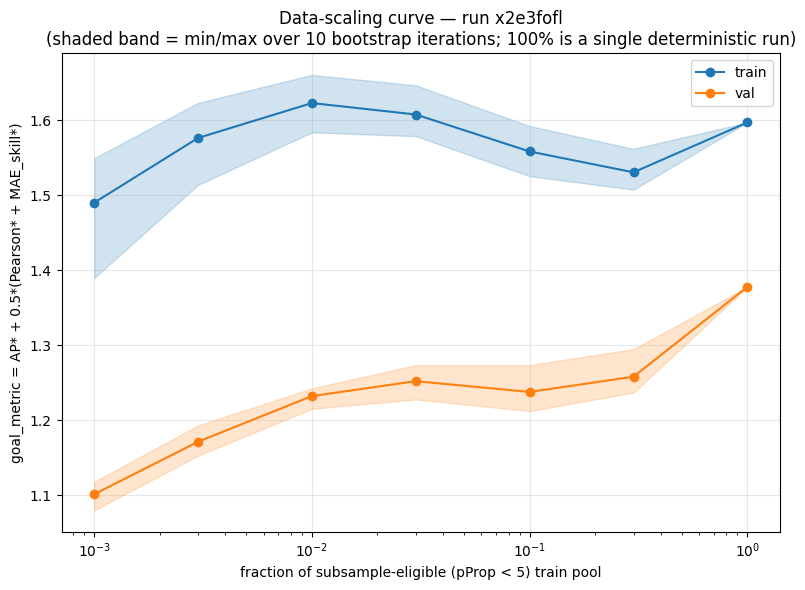

In [9]:
fig, ax = plt.subplots(figsize=(8, 6))

ax.plot(agg["fraction"], agg["train_mean"], marker="o", color="tab:blue", label="train")
ax.fill_between(agg["fraction"], agg["train_min"], agg["train_max"], color="tab:blue", alpha=0.2)

ax.plot(agg["fraction"], agg["val_mean"], marker="o", color="tab:orange", label="val")
ax.fill_between(agg["fraction"], agg["val_min"], agg["val_max"], color="tab:orange", alpha=0.2)

ax.set_xscale("log")
ax.set_xlabel("fraction of subsample-eligible (pProp < 5) train pool")
ax.set_ylabel("goal_metric = AP* + 0.5*(Pearson* + MAE_skill*)")
ax.set_title(f"Data-scaling curve — run {RUN_ID}\n"
             f"(shaded band = min/max over {N_BOOTSTRAP} bootstrap iterations; "
             f"100% is a single deterministic run)")
ax.legend()
ax.grid(alpha=0.3)
fig.tight_layout()
plt.show()

## Sanity check

The 100% row retrains from a fresh random init on the exact same molecules the
source run used, so its `val_goal_metric` should land in the same ballpark as
the source run's own reported value (small deviations are expected -- this is
a fresh init/optimizer/scheduler, not the source run's saved weights).

In [10]:
row_100 = df[df["fraction"] >= 1.0].iloc[0]
print(f"source run  ({RUN_ID}) val_goal_metric: {meta['val_goal_metric']:.4f}")
print(f"this notebook's 100% retrain val_goal_metric: {row_100['val_goal_metric']:.4f}")

source run  (x2e3fofl) val_goal_metric: 1.4413
this notebook's 100% retrain val_goal_metric: 1.2275
